In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Student_Performance.csv")

In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 493.2 KB


In [8]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='str')

In [9]:
df=pd.read_csv("Student_Performance.csv")

In [10]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

<Axes: >

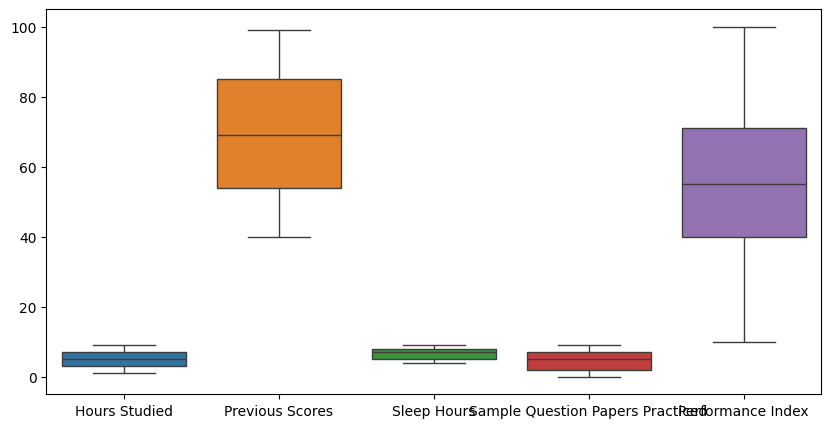

In [12]:
# boxplot for outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df)#feature scaling


In [19]:
#feature scaling
numeric_cols = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Study_Sleep_Score',
    'Performance_Efficiency',
    'Practice_Effectiveness'
]

In [20]:
#feature engineering
df['Study_Sleep_Score'] = (
    df['Hours Studied'] + df['Sleep Hours']
)
df['Performance_Efficiency'] = (
    df['Performance Index'] / (df['Hours Studied'] + 1)
)
df['Practice_Effectiveness'] = (
    df['Sample Question Papers Practiced'] *
    df['Hours Studied']
)

In [21]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index',
       'Study_Sleep_Score', 'Performance_Efficiency',
       'Practice_Effectiveness'],
      dtype='str')

In [22]:
# Separate input features and target (assuming 'Performance Index' is the target as the last column in the original data)
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [25]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Study_Sleep_Score,Performance_Efficiency,Practice_Effectiveness
0,7,99,Yes,9,1,16,11.375000,7
1,4,82,No,4,2,8,13.000000,8
2,8,51,Yes,7,2,15,5.000000,16
3,5,52,Yes,5,2,10,6.000000,10
4,7,75,No,8,5,15,8.250000,35
...,...,...,...,...,...,...,...,...
9995,1,49,Yes,4,2,5,11.500000,2
9996,7,64,Yes,8,5,15,7.250000,35
9997,6,83,Yes,8,5,14,10.571429,30
9998,9,97,Yes,7,0,16,9.500000,0


In [26]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

In [28]:
X.shape

(10000, 8)

In [29]:
y.shape

(10000,)

In [24]:
#divide the data into training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)